<a href="https://colab.research.google.com/github/TheAIRhishi/AGI_AI_B.S.2083/blob/main/Time_seriesGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, TensorDataset


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [ ]:

seq_len = 40
features = 10
n_embd = 512
n_head = 8
n_layer = 4
batch_size = 64
epochs = 8



In [ ]:

T = 1000

A = np.random.randn(features, features) * 0.25


A.shape



(10, 10)

In [ ]:
x = np.random.randn(features)
x.shape

(10,)

In [ ]:
data = []

In [ ]:

for t in range(T):
    data.append(x)
    x = np.tanh(A @ x) + 0.05*np.random.randn(features)




In [ ]:
0.05*np.random.randn(features)

array([-0.01586132, -0.0048173 ,  0.101643  ,  0.02071178,  0.00131587,
        0.01154918,  0.01860973,  0.05113845,  0.01665923, -0.02861187])

In [ ]:


T = 1000

A = np.random.randn(features, features) * 0.25

x = np.random.randn(features)
data = []

for t in range(T):
    data.append(x)
    x = np.tanh(A @ x) + 0.05*np.random.randn(features)



In [ ]:
data = np.array(data)
print(data.shape)

(1000, 10)


In [ ]:


train_data = data[:700]
test_data = data[700:]



In [ ]:

def make_windows(arr, seq_len):

    X=[]
    Y=[]

    for i in range(len(arr)-seq_len):

        X.append(arr[i:i+seq_len])
        Y.append(arr[i+1:i+seq_len+1])

    return np.array(X), np.array(Y)


In [ ]:


train_x, train_y = make_windows(train_data, seq_len)
test_x, test_y = make_windows(test_data, seq_len)

print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)



(660, 40, 10) (660, 40, 10)
(260, 40, 10) (260, 40, 10)


In [ ]:

train_x = torch.tensor(train_x,dtype=torch.float32)
train_y = torch.tensor(train_y,dtype=torch.float32)

test_x = torch.tensor(test_x,dtype=torch.float32)
test_y = torch.tensor(test_y,dtype=torch.float32)



In [ ]:

train_loader = DataLoader(
    TensorDataset(train_x,train_y),
    batch_size=batch_size,
    shuffle=False
)


In [ ]:
class FeedForward(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd,4*n_embd),
            nn.GELU(),
            nn.Linear(4*n_embd,n_embd)
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
class Head(nn.Module):

    def __init__(self, head_size):
        super().__init__()



        self.key = nn.Linear(n_embd,head_size,bias=False)
        self.query = nn.Linear(n_embd,head_size,bias=False)
        self.value = nn.Linear(n_embd,head_size,bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(seq_len,seq_len))
        )

    def forward(self,x):

        B,T,E = x.shape

        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2,-1) * (k.shape[-1] ** -0.5)

        wei = wei.masked_fill(
            self.tril[:T,:T]==0,
            float('-inf')
        )

        wei = F.softmax(wei,dim=-1)

        v = self.value(x)

        return wei @ v

In [ ]:
class MultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        head_size = n_embd // n_head

        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(n_head)]
        )

        self.proj = nn.Linear(n_embd,n_embd)

    def forward(self,x):

        x = torch.cat([h(x) for h in self.heads],dim=-1)

        return self.proj(x)

In [ ]:
class Block(nn.Module):

    def __init__(self):
        super().__init__()

        self.sa = MultiHead()
        self.ff = FeedForward()

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self,x):

        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))

        return x

In [ ]:
# ============================================================
# TIME SERIES GPT
# ============================================================

class TimeSeriesGPT(nn.Module):

    def __init__(self):
        super().__init__()

        self.feature_proj = nn.Linear(features,n_embd)

        self.pos_emb = nn.Embedding(seq_len,n_embd)

        self.blocks = nn.Sequential(
            *[Block() for _ in range(n_layer)]
        )

        self.ln = nn.LayerNorm(n_embd)

        self.head = nn.Linear(n_embd,features)

    def forward(self,x):

        B,T,F = x.shape

        x = self.feature_proj(x)  ## 64, 40, 10  > 64, 40, 512

        pos = torch.arange(T,device=x.device)

      ## 64, 40, 512      64,40, 512


        x = x       +   self.pos_emb(pos)

        x = self.blocks(x)

        x = self.ln(x)

        return self.head(x)

In [ ]:


model = TimeSeriesGPT().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=3e-4)




In [ ]:
# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for xb,yb in train_loader:

        xb=xb.to(device)
        yb=yb.to(device)

        pred = model(xb)

        loss = F.mse_loss(pred,yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("epoch",epoch,"loss",total_loss/len(train_loader))

epoch 0 loss 0.26719706607135857
epoch 1 loss 0.02703627808527513
epoch 2 loss 0.011169720483435825
epoch 3 loss 0.006473523268306797
epoch 4 loss 0.004831898280165412
epoch 5 loss 0.004238230218602853
epoch 6 loss 0.0039250132924115114
epoch 7 loss 0.003737801474265077


In [ ]:
# ============================================================
# TEST EVALUATION
# ============================================================

model.eval()

with torch.no_grad():

    xb = test_x.to(device)

    pred = model(xb).cpu().numpy()

    true = test_y.numpy()

In [ ]:
mse = np.mean((pred-true)**2)

r2 = r2_score(
    true.reshape(-1,features),
    pred.reshape(-1,features)
)

print("Test MSE:",mse)
print("Test R2 :",r2)

Test MSE: 0.0034405706
Test R2 : 0.2071632444858551


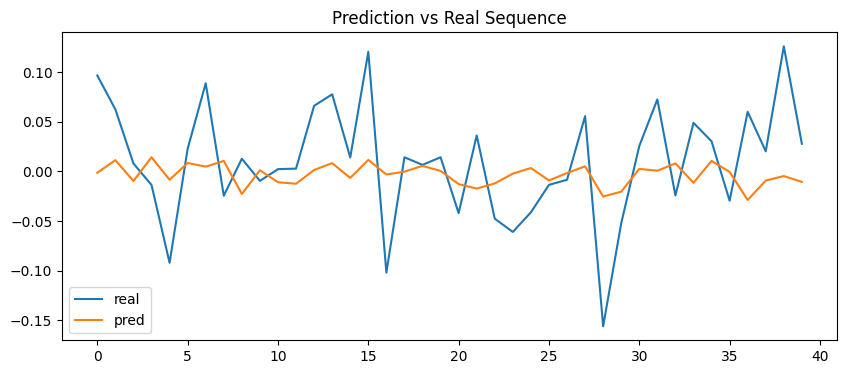

In [ ]:

# ============================================================
# PLOT PREDICTED VS REAL
# ============================================================

feature_id = 0

plt.figure(figsize=(10,4))

plt.plot(true[0,:,feature_id],label="real")

plt.plot(pred[0,:,feature_id],label="pred")

plt.legend()

plt.title("Prediction vs Real Sequence")

plt.show()

